In [26]:
import pandas as pd
import matplotlib.pyplot as plt

In [27]:
import pyodbc

conn = pyodbc.connect(
    "DRIVER={ODBC Driver 17 for SQL Server};"
    "SERVER=ANIKETPARIDA\\SQLEXPRESS03;"
    "DATABASE=E_shop;"
    "Trusted_Connection=yes"
)
query = "SELECT * FROM eshop_sample"
df = pd.read_sql(query,conn)
df

C:\Users\Dell\AppData\Local\Temp\ipykernel_28496\3254047296.py:10: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql(query,conn)


,date,session_id,channel,source,medium,campaign,device_category,country,is_new_user,pageviews,time_on_site_sec,product_views,add_to_cart,checkout_started,transactions,revenue_usd,estimated_marketing_cost
0,2024-04-05,1.0,Email,crm,email,Campaign_1,Desktop,India,True,12,115,True,True,True,True,391.809998,0.51
1,2024-03-19,2.0,Referral,partner,referral,None,Tablet,UK,True,6,345,True,True,False,False,0.000000,0.00
2,2024-04-09,3.0,Email,crm,email,Campaign_3,Desktop,France,False,3,355,True,False,False,False,0.000000,0.53
3,2024-02-25,4.0,Referral,partner,referral,None,Desktop,UK,True,1,867,False,False,False,False,0.000000,0.00
4,2024-04-25,5.0,Referral,partner,referral,None,Desktop,Germany,True,5,249,True,False,False,False,0.000000,0.00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,2024-03-31,9996.0,Paid Search,google,cpc,Campaign_4,Desktop,India,True,11,839,True,True,True,True,402.320007,2.43
9996,2024-02-21,9997.0,Email,crm,email,Campaign_6,Tablet,France,True,4,678,True,False,False,False,0.000000,1.33
9997,2024-04-18,9998.0,Paid Social,facebook,cpc,Campaign_1,Desktop,UK,True,6,395,True,False,False,False,0.000000,5.47
9998,2024-04-09,9999.0,Referral,partner,referral,None,Desktop,United States,True,8,276,True,True,False,False,0.000000,0.00


In [28]:
change_type = df.astype({"is_new_user":"int",
           "product_views":"int",
           "add_to_cart":"int",
           "checkout_started":"int",
           "transactions":"int",
           "session_id":"int"})
change_type

,date,session_id,channel,source,medium,campaign,device_category,country,is_new_user,pageviews,time_on_site_sec,product_views,add_to_cart,checkout_started,transactions,revenue_usd,estimated_marketing_cost
0,2024-04-05,1,Email,crm,email,Campaign_1,Desktop,India,1,12,115,1,1,1,1,391.809998,0.51
1,2024-03-19,2,Referral,partner,referral,None,Tablet,UK,1,6,345,1,1,0,0,0.000000,0.00
2,2024-04-09,3,Email,crm,email,Campaign_3,Desktop,France,0,3,355,1,0,0,0,0.000000,0.53
3,2024-02-25,4,Referral,partner,referral,None,Desktop,UK,1,1,867,0,0,0,0,0.000000,0.00
4,2024-04-25,5,Referral,partner,referral,None,Desktop,Germany,1,5,249,1,0,0,0,0.000000,0.00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,2024-03-31,9996,Paid Search,google,cpc,Campaign_4,Desktop,India,1,11,839,1,1,1,1,402.320007,2.43
9996,2024-02-21,9997,Email,crm,email,Campaign_6,Tablet,France,1,4,678,1,0,0,0,0.000000,1.33
9997,2024-04-18,9998,Paid Social,facebook,cpc,Campaign_1,Desktop,UK,1,6,395,1,0,0,0,0.000000,5.47
9998,2024-04-09,9999,Referral,partner,referral,None,Desktop,United States,1,8,276,1,1,0,0,0.000000,0.00


In [29]:
# Clean the Data into the table
count_duplicate = change_type.duplicated().sum()
Empty_row = change_type.isna().sum()
fill_empty = change_type.fillna(0)
fill_empty

,date,session_id,channel,source,medium,campaign,device_category,country,is_new_user,pageviews,time_on_site_sec,product_views,add_to_cart,checkout_started,transactions,revenue_usd,estimated_marketing_cost
0,2024-04-05,1,Email,crm,email,Campaign_1,Desktop,India,1,12,115,1,1,1,1,391.809998,0.51
1,2024-03-19,2,Referral,partner,referral,0,Tablet,UK,1,6,345,1,1,0,0,0.000000,0.00
2,2024-04-09,3,Email,crm,email,Campaign_3,Desktop,France,0,3,355,1,0,0,0,0.000000,0.53
3,2024-02-25,4,Referral,partner,referral,0,Desktop,UK,1,1,867,0,0,0,0,0.000000,0.00
4,2024-04-25,5,Referral,partner,referral,0,Desktop,Germany,1,5,249,1,0,0,0,0.000000,0.00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,2024-03-31,9996,Paid Search,google,cpc,Campaign_4,Desktop,India,1,11,839,1,1,1,1,402.320007,2.43
9996,2024-02-21,9997,Email,crm,email,Campaign_6,Tablet,France,1,4,678,1,0,0,0,0.000000,1.33
9997,2024-04-18,9998,Paid Social,facebook,cpc,Campaign_1,Desktop,UK,1,6,395,1,0,0,0,0.000000,5.47
9998,2024-04-09,9999,Referral,partner,referral,0,Desktop,United States,1,8,276,1,1,0,0,0.000000,0.00


In [30]:
total_revenue_usd = fill_empty["revenue_usd"].sum()
print(f"Total_revenue {total_revenue_usd:.2f}")

Total_revenue 391875.91


In [31]:
total_marketing_cost = fill_empty["estimated_marketing_cost"].sum()
new_customer = fill_empty[fill_empty["is_new_user"] == 1]["session_id"].nunique()
customer_aquazition_cost = total_marketing_cost / new_customer
print(f"Customer_aquazation_Cost {customer_aquazition_cost:.2f}")

Customer_aquazation_Cost 3.32


In [32]:
average_revenue = fill_empty["revenue_usd"].mean()
print(f"Average Revenue {average_revenue:.2f}")

Average Revenue 39.19


In [33]:
fill_empty['date'] = pd.to_datetime(fill_empty["date"])
fill_empty["Month"] = fill_empty["date"].dt.month
fill_empty["Month_Name"] = fill_empty["date"].dt.month_name()
fill_empty

,date,session_id,channel,source,medium,campaign,device_category,country,is_new_user,pageviews,time_on_site_sec,product_views,add_to_cart,checkout_started,transactions,revenue_usd,estimated_marketing_cost,Month,Month_Name
0,2024-04-05,1,Email,crm,email,Campaign_1,Desktop,India,1,12,115,1,1,1,1,391.809998,0.51,4,April
1,2024-03-19,2,Referral,partner,referral,0,Tablet,UK,1,6,345,1,1,0,0,0.000000,0.00,3,March
2,2024-04-09,3,Email,crm,email,Campaign_3,Desktop,France,0,3,355,1,0,0,0,0.000000,0.53,4,April
3,2024-02-25,4,Referral,partner,referral,0,Desktop,UK,1,1,867,0,0,0,0,0.000000,0.00,2,February
4,2024-04-25,5,Referral,partner,referral,0,Desktop,Germany,1,5,249,1,0,0,0,0.000000,0.00,4,April
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,2024-03-31,9996,Paid Search,google,cpc,Campaign_4,Desktop,India,1,11,839,1,1,1,1,402.320007,2.43,3,March
9996,2024-02-21,9997,Email,crm,email,Campaign_6,Tablet,France,1,4,678,1,0,0,0,0.000000,1.33,2,February
9997,2024-04-18,9998,Paid Social,facebook,cpc,Campaign_1,Desktop,UK,1,6,395,1,0,0,0,0.000000,5.47,4,April
9998,2024-04-09,9999,Referral,partner,referral,0,Desktop,United States,1,8,276,1,1,0,0,0.000000,0.00,4,April


In [34]:
change_dtype = fill_empty.astype({"date":"date32[pyarrow]"})
change_dtype

,date,session_id,channel,source,medium,campaign,device_category,country,is_new_user,pageviews,time_on_site_sec,product_views,add_to_cart,checkout_started,transactions,revenue_usd,estimated_marketing_cost,Month,Month_Name
0,2024-04-05,1,Email,crm,email,Campaign_1,Desktop,India,1,12,115,1,1,1,1,391.809998,0.51,4,April
1,2024-03-19,2,Referral,partner,referral,0,Tablet,UK,1,6,345,1,1,0,0,0.000000,0.00,3,March
2,2024-04-09,3,Email,crm,email,Campaign_3,Desktop,France,0,3,355,1,0,0,0,0.000000,0.53,4,April
3,2024-02-25,4,Referral,partner,referral,0,Desktop,UK,1,1,867,0,0,0,0,0.000000,0.00,2,February
4,2024-04-25,5,Referral,partner,referral,0,Desktop,Germany,1,5,249,1,0,0,0,0.000000,0.00,4,April
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,2024-03-31,9996,Paid Search,google,cpc,Campaign_4,Desktop,India,1,11,839,1,1,1,1,402.320007,2.43,3,March
9996,2024-02-21,9997,Email,crm,email,Campaign_6,Tablet,France,1,4,678,1,0,0,0,0.000000,1.33,2,February
9997,2024-04-18,9998,Paid Social,facebook,cpc,Campaign_1,Desktop,UK,1,6,395,1,0,0,0,0.000000,5.47,4,April
9998,2024-04-09,9999,Referral,partner,referral,0,Desktop,United States,1,8,276,1,1,0,0,0.000000,0.00,4,April


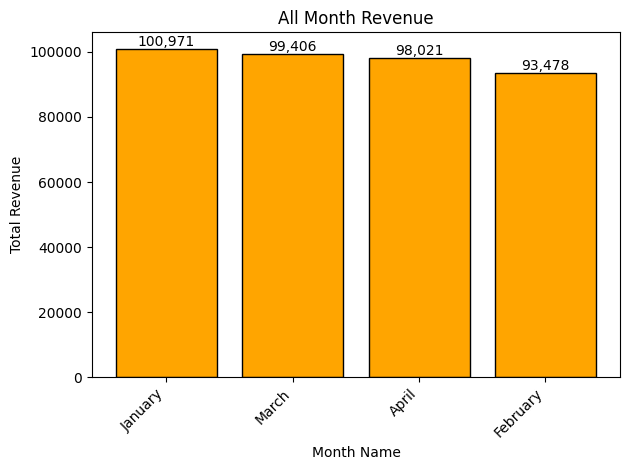

In [35]:
all_month_revenue = change_dtype.groupby(change_dtype["Month_Name"])["revenue_usd"].sum().sort_values(ascending=False)
plt.Figure(figsize=(20,8))
bars = plt.bar(all_month_revenue.index,all_month_revenue.values,color="orange",edgecolor="black")
plt.xlabel("Month Name")
plt.ylabel("Total Revenue")
plt.title("All Month Revenue")
for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        height,
        f'{height:,.0f}',
        ha='center',
        va='bottom'
    )
plt.xticks(rotation=45,ha='right')
plt.tight_layout()
plt.show()

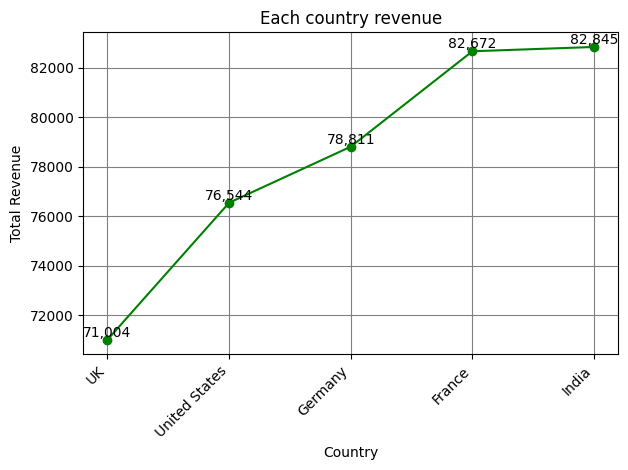

In [36]:
country_revenue = change_dtype.groupby(change_dtype["country"])["revenue_usd"].sum().sort_values(ascending=True)
plt.Figure(figsize=(20,8))
plt.plot(country_revenue.index,country_revenue.values,marker="o",color="green",linestyle="-")
plt.xlabel("Country")
plt.ylabel("Total Revenue")
plt.title("Each country revenue")

for x,y in zip(country_revenue.index,country_revenue.values):
    plt.text(
        x,
        y,
        f"{y:,.0f}",
        ha="center",
        va = "bottom")

plt.xticks(rotation=45,ha='right')
plt.tight_layout()
plt.grid(color="gray")
plt.show()

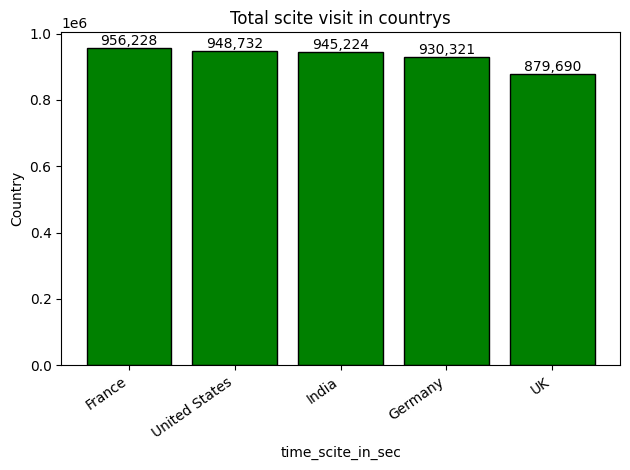

In [37]:
time_in_seits_sec = change_dtype.groupby([change_dtype["country"]])["time_on_site_sec"].sum().sort_values(ascending=False)
bars = plt.bar(time_in_seits_sec.index,time_in_seits_sec.values,color="Green",edgecolor='black')
plt.xlabel("time_scite_in_sec")
plt.ylabel("Country")
plt.title("Total scite visit in countrys")

for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        height,
        f'{height:,.0f}',
        ha='center',
        va='bottom'
    )
plt.xticks(rotation=35,ha='right')
plt.tight_layout()
plt.show()
    

In [38]:
total_campaine = change_dtype["campaign"].value_counts()
total_campaine

campaign
0             5048
Campaign_7     679
Campaign_3     643
Campaign_5     636
Campaign_1     616
Campaign_2     606
Campaign_8     603
Campaign_6     588
Campaign_4     581
Name: count, dtype: int64

In [39]:
# Supervice learning 
# Liner regresion
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error,r2_score,mean_squared_error

X = change_dtype[["estimated_marketing_cost","add_to_cart","pageviews"]]
y = change_dtype["revenue_usd"]

X_train,X_test,y_train,y_test = train_test_split(X,y,train_size=0.2,random_state=48)

model = LinearRegression()
model.fit(X_train,y_train)

r_predic = model.predict(X_test)

print("MAE",mean_absolute_error(y_test,r_predic))
print("MSE",mean_squared_error(y_test,r_predic))
print("r2_score",r2_score(y_test,r_predic))

MAE 54.60379782136304
MSE 9269.35907663215
r2_score 0.18576234747880183


In [40]:
# Logestic Regression
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score,confusion_matrix,classification_report,f1_score

X = change_dtype[["estimated_marketing_cost","add_to_cart"]]
y = change_dtype["revenue_usd"]

y_binary = (y > y.median()).astype(int)
X_train,X_test,y_train,y_test = train_test_split(X,y_binary,train_size=0.2,random_state=48)

model = LogisticRegression()
model.fit(X_train,y_train)

r_pred = model.predict(X_test)

print("confusion_matrix",confusion_matrix(y_test,r_pred))
print("accuracy_score",accuracy_score(y_test,r_pred))
print("classification_report",classification_report(y_test,r_pred))
print("f1_score",f1_score(y_test,r_pred))

confusion_matrix [[6885    0]
 [1115    0]]
accuracy_score 0.860625
classification_report               precision    recall  f1-score   support

           0       0.86      1.00      0.93      6885
           1       0.00      0.00      0.00      1115

    accuracy                           0.86      8000
   macro avg       0.43      0.50      0.46      8000
weighted avg       0.74      0.86      0.80      8000

f1_score 0.0


C:\Users\Dell\AppData\Roaming\Python\Python313\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\Dell\AppData\Roaming\Python\Python313\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\Dell\AppData\Roaming\Python\Python313\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize

In [42]:
# dision tree
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.preprocessing import LabelEncoder

X = change_dtype[["estimated_marketing_cost"]]
y = change_dtype["revenue_usd"]

le_category = LabelEncoder()
X_encoded = X.copy()
X_encoded["estimated_marketing_cost"] = le_category.fit_transform(X["estimated_marketing_cost"])

le_status = LabelEncoder()
y_encoded = le_category.fit_transform(y)

X_train,X_test,y_train,y_test = train_test_split(X_encoded,y_encoded,train_size=0.2,random_state=48)

model = DecisionTreeClassifier()
model.fit(X_train,y_train)

print("Accuracy",model.score(X_test,y_test))

Accuracy 0.832125


In [43]:
change_dtype

,date,session_id,channel,source,medium,campaign,device_category,country,is_new_user,pageviews,time_on_site_sec,product_views,add_to_cart,checkout_started,transactions,revenue_usd,estimated_marketing_cost,Month,Month_Name
0,2024-04-05,1,Email,crm,email,Campaign_1,Desktop,India,1,12,115,1,1,1,1,391.809998,0.51,4,April
1,2024-03-19,2,Referral,partner,referral,0,Tablet,UK,1,6,345,1,1,0,0,0.000000,0.00,3,March
2,2024-04-09,3,Email,crm,email,Campaign_3,Desktop,France,0,3,355,1,0,0,0,0.000000,0.53,4,April
3,2024-02-25,4,Referral,partner,referral,0,Desktop,UK,1,1,867,0,0,0,0,0.000000,0.00,2,February
4,2024-04-25,5,Referral,partner,referral,0,Desktop,Germany,1,5,249,1,0,0,0,0.000000,0.00,4,April
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,2024-03-31,9996,Paid Search,google,cpc,Campaign_4,Desktop,India,1,11,839,1,1,1,1,402.320007,2.43,3,March
9996,2024-02-21,9997,Email,crm,email,Campaign_6,Tablet,France,1,4,678,1,0,0,0,0.000000,1.33,2,February
9997,2024-04-18,9998,Paid Social,facebook,cpc,Campaign_1,Desktop,UK,1,6,395,1,0,0,0,0.000000,5.47,4,April
9998,2024-04-09,9999,Referral,partner,referral,0,Desktop,United States,1,8,276,1,1,0,0,0.000000,0.00,4,April


In [47]:
# Rendom Forest
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score

X = change_dtype[["estimated_marketing_cost","Month"]]
y = change_dtype["revenue_usd"]

X_train,X_test,y_train,y_test = train_test_split(X,y,train_size=0.2,random_state=48)

model = RandomForestRegressor(
    n_estimators=100,
    max_depth=10,
    random_state=42)
model.fit(X_train,y_train)

r_predic = model.predict(X_test)

print("r2_score",r2_score(y_test,r_predic))

r2_score -0.07102829548626066
